## 1. Imports et Configuration


In [ ]:
import os, sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / 'config.py').exists():
    for parent in ROOT.parents:
        if (parent / 'config.py').exists():
            ROOT = parent
            break
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from config import (
    BASE_DIR, DATA_DIR, RAW_DIR, IMAGES_DIR, ARTIFACTS_DIR,
    NOTEBOOKS_DIR, ANDROID_ASSETS_DIR, TESTS_DIR, DIAGNOSTICS_DIR,
    ensure_kaggle_credentials, ensure_kaggle_dataset, describe_config,
    artifacts_for,
 )

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
import time
from PIL import Image
from pathlib import Path
import pandas as pd

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

print('Working dir set to', ROOT)
print(describe_config())


TensorFlow version: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Imports OK!


## 2. Configuration et Hyperparamètres


In [ ]:
# Chemins
DATA_DIR = IMAGES_DIR
OUTPUT_DIR = artifacts_for("multitask", "multitask_model")
ARTIFACTS_DIR = OUTPUT_DIR

# Hyperparamètres
IMG_SIZE = 128
BATCH_SIZE = 32
WARMUP_EPOCHS = 15
FINETUNE_EPOCHS = 40
INITIAL_LR = 1e-3
FINETUNE_LR = 1e-5

# Splits
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15

# Classes
ETHNICITY_CLASSES = ["White", "Black", "Asian", "Indian", "Others"]
GENDER_CLASSES = ["Male", "Female"]

print(f"Dataset: {DATA_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"Configuration:")
print(f"  - Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Warmup epochs: {WARMUP_EPOCHS}")
print(f"  - Finetune epochs: {FINETUNE_EPOCHS}")

Configuration:
  - Image size: 128x128
  - Batch size: 32
  - Warmup epochs: 15
  - Finetune epochs: 40


## 3. Chargement des Données UTKFace


In [3]:
def parse_utkface_filename(filepath):
    """Parse le nom de fichier UTKFace: [age]_[gender]_[race]_[date&time].jpg"""
    filename = Path(filepath).stem
    parts = filename.split("_")

    if len(parts) >= 3:
        try:
            age = int(parts[0])
            gender = int(parts[1])  # 0: Male, 1: Female
            ethnicity = int(parts[2])  # 0-4

            if 0 <= age <= 116 and gender in [0, 1] and 0 <= ethnicity <= 4:
                return {
                    "filepath": str(filepath),
                    "age": age,
                    "gender": gender,
                    "ethnicity": ethnicity,
                }
        except (ValueError, IndexError):
            pass
    return None


# Charger toutes les images
image_paths = list(DATA_DIR.glob("*.jpg")) + list(DATA_DIR.glob("*.JPG"))
print(f"Images trouvées: {len(image_paths)}")

# Parser les métadonnées
records = []
for path in tqdm(image_paths, desc="Parsing filenames"):
    record = parse_utkface_filename(path)
    if record:
        records.append(record)

df = pd.DataFrame(records)
print(f"\nImages valides: {len(df)}")
print(f"\nDistribution des âges:")
print(df["age"].describe())
print(f"\nDistribution des genres:")
print(df["gender"].value_counts())
print(f"\nDistribution des ethnicités:")
print(df["ethnicity"].value_counts())

Images trouvées: 23708


Parsing filenames: 100%|██████████| 23708/23708 [00:00<00:00, 348030.43it/s]


Images valides: 23705

Distribution des âges:
count    23705.000000
mean        33.300907
std         19.885708
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64

Distribution des genres:
gender
0    12391
1    11314
Name: count, dtype: int64

Distribution des ethnicités:
ethnicity
0    10078
1     4526
3     3975
2     3434
4     1692
Name: count, dtype: int64


## 4. Nettoyage des Données (Outliers)


In [4]:
# Retirer les outliers d'âge (Z-score > 3)
z_scores = np.abs(stats.zscore(df["age"]))
outliers_mask = z_scores > 3
n_outliers = outliers_mask.sum()

print(f"Outliers détectés: {n_outliers}")
print(f"Âges outliers: {df[outliers_mask]['age'].unique()}")

df_clean = df[~outliers_mask].copy()
print(f"\nDataset après nettoyage: {len(df_clean)} images")

Outliers détectés: 72
Âges outliers: [100  99  96 110  95 105 111 103 116 115  93 101]

Dataset après nettoyage: 23633 images


## 5. Split Train/Val/Test


In [5]:
# Extraire les données
X = df_clean["filepath"].values
y_age = df_clean["age"].values.astype(np.float32)
y_gender = df_clean["gender"].values.astype(np.int32)
y_ethnicity = df_clean["ethnicity"].values.astype(np.int32)

# Premier split: train+val vs test
(
    X_trainval,
    X_test,
    y_age_trainval,
    y_age_test,
    y_gender_trainval,
    y_gender_test,
    y_eth_trainval,
    y_eth_test,
) = train_test_split(
    X,
    y_age,
    y_gender,
    y_ethnicity,
    test_size=TEST_SPLIT,
    random_state=SEED,
    stratify=y_ethnicity,  # Stratifier sur l'ethnicité (la plus déséquilibrée)
)

# Deuxième split: train vs val
val_ratio = VAL_SPLIT / (1 - TEST_SPLIT)
(
    X_train,
    X_val,
    y_age_train,
    y_age_val,
    y_gender_train,
    y_gender_val,
    y_eth_train,
    y_eth_val,
) = train_test_split(
    X_trainval,
    y_age_trainval,
    y_gender_trainval,
    y_eth_trainval,
    test_size=val_ratio,
    random_state=SEED,
    stratify=y_eth_trainval,
)

print(f"Split des données:")
print(f"  - Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Val: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"  - Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

Split des données:
  - Train: 16543 (70.0%)
  - Val: 3545 (15.0%)
  - Test: 3545 (15.0%)


## 6. Calcul des Poids de Classes


In [6]:
# Poids pour le genre
gender_weights = compute_class_weight(
    "balanced", classes=np.unique(y_gender_train), y=y_gender_train
)
gender_class_weights = dict(enumerate(gender_weights))
print(f"Poids des classes (genre): {gender_class_weights}")

# Poids pour l'ethnicité
ethnicity_weights = compute_class_weight(
    "balanced", classes=np.unique(y_eth_train), y=y_eth_train
)
ethnicity_class_weights = dict(enumerate(ethnicity_weights))
print(f"Poids des classes (ethnicité): {ethnicity_class_weights}")

Poids des classes (genre): {0: np.float64(0.9554695622039968), 1: np.float64(1.0488840984022318)}
Poids des classes (ethnicité): {0: np.float64(0.4710421412300683), 1: np.float64(1.045701643489254), 2: np.float64(1.3837724801338351), 3: np.float64(1.1901438848920862), 4: np.float64(2.794425675675676)}


## 7. Data Augmentation


In [7]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.15),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomBrightness(0.2),
        layers.RandomContrast(0.2),
    ],
    name="data_augmentation",
)

print("Data augmentation configurée:")
for layer in data_augmentation.layers:
    print(f"  - {layer.name}")

I0000 00:00:1768742187.234834   99420 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4081 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Data augmentation configurée:
  - random_flip
  - random_rotation
  - random_zoom
  - random_translation
  - random_brightness
  - random_contrast


## 8. Pipeline de Données tf.data


In [8]:
def load_and_preprocess(filepath, age, gender, ethnicity):
    """Charge et prétraite une image."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)  # [0, 255]
    return img, {
        "age_output": age,
        "gender_output": gender,
        "ethnicity_output": ethnicity,
    }


def create_dataset(filepaths, ages, genders, ethnicities, training=False):
    """Crée un tf.data.Dataset."""
    ds = tf.data.Dataset.from_tensor_slices((filepaths, ages, genders, ethnicities))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=1000)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


# Créer les datasets
train_ds = create_dataset(
    X_train, y_age_train, y_gender_train, y_eth_train, training=True
)
val_ds = create_dataset(X_val, y_age_val, y_gender_val, y_eth_val, training=False)
test_ds = create_dataset(X_test, y_age_test, y_gender_test, y_eth_test, training=False)

print(f"Datasets créés:")
print(f"  - Train: {len(X_train)} images")
print(f"  - Val: {len(X_val)} images")
print(f"  - Test: {len(X_test)} images")

Datasets créés:
  - Train: 16543 images
  - Val: 3545 images
  - Test: 3545 images


## 9. Architecture du Modèle Multi-Tâche

```
                    ┌─────────────────────────────────────┐
                    │         Input (128x128x3)           │
                    └─────────────────┬───────────────────┘
                                      │
                    ┌─────────────────▼───────────────────┐
                    │     Data Augmentation (train)       │
                    └─────────────────┬───────────────────┘
                                      │
                    ┌─────────────────▼───────────────────┐
                    │   EfficientNetB0 (Backbone partagé) │
                    │        Pré-entraîné ImageNet        │
                    └─────────────────┬───────────────────┘
                                      │
                    ┌─────────────────▼───────────────────┐
                    │   GlobalAveragePooling2D + GMP      │
                    │        (Features partagées)         │
                    └─────────────────┬───────────────────┘
                                      │
                    ┌─────────────────▼───────────────────┐
                    │      Dense 512 + BN + Dropout       │
                    │        (Représentation commune)     │
                    └─────────────────┬───────────────────┘
                                      │
          ┌───────────────────────────┼───────────────────────────┐
          │                           │                           │
          ▼                           ▼                           ▼
┌─────────────────┐         ┌─────────────────┐         ┌─────────────────┐
│   🎂 Age Head   │         │  👫 Gender Head │         │ 🌍 Ethnicity    │
│   Dense 128     │         │   Dense 128     │         │   Dense 128     │
│   Dense 1       │         │   Dense 1       │         │   Dense 5       │
│   (linéaire)    │         │   (sigmoid)     │         │   (softmax)     │
└─────────────────┘         └─────────────────┘         └─────────────────┘
```


In [9]:
def build_multitask_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), training=True):
    """Construit le modèle multi-tâche."""

    # Input
    inputs = layers.Input(shape=input_shape, name="input_image")

    # Data augmentation (uniquement pendant l'entraînement)
    x = data_augmentation(inputs) if training else inputs

    # Backbone: EfficientNetB0
    backbone = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=x)
    backbone.trainable = False  # Gelé initialement

    features = backbone.output

    # Double pooling
    gap = layers.GlobalAveragePooling2D(name="gap")(features)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(features)
    pooled = layers.Concatenate(name="concat_pooling")([gap, gmp])

    # Couches partagées
    shared = layers.Dense(
        512, activation="relu", kernel_regularizer=l2(1e-4), name="shared_dense"
    )(pooled)
    shared = layers.BatchNormalization(name="shared_bn")(shared)
    shared = layers.Dropout(0.4, name="shared_dropout")(shared)

    # === HEAD ÂGE (Régression) ===
    age_branch = layers.Dense(
        128, activation="relu", kernel_regularizer=l2(1e-4), name="age_dense1"
    )(shared)
    age_branch = layers.BatchNormalization(name="age_bn")(age_branch)
    age_branch = layers.Dropout(0.3, name="age_dropout")(age_branch)
    age_output = layers.Dense(1, activation="linear", name="age_output")(age_branch)

    # === HEAD GENRE (Classification binaire) ===
    gender_branch = layers.Dense(
        128, activation="relu", kernel_regularizer=l2(1e-4), name="gender_dense1"
    )(shared)
    gender_branch = layers.BatchNormalization(name="gender_bn")(gender_branch)
    gender_branch = layers.Dropout(0.3, name="gender_dropout")(gender_branch)
    gender_output = layers.Dense(1, activation="sigmoid", name="gender_output")(
        gender_branch
    )

    # === HEAD ETHNICITÉ (Classification multi-classe) ===
    ethnicity_branch = layers.Dense(
        128, activation="relu", kernel_regularizer=l2(1e-4), name="ethnicity_dense1"
    )(shared)
    ethnicity_branch = layers.BatchNormalization(name="ethnicity_bn")(ethnicity_branch)
    ethnicity_branch = layers.Dropout(0.3, name="ethnicity_dropout")(ethnicity_branch)
    ethnicity_output = layers.Dense(5, activation="softmax", name="ethnicity_output")(
        ethnicity_branch
    )

    # Modèle final
    model = Model(
        inputs=inputs,
        outputs=[age_output, gender_output, ethnicity_output],
        name="multitask_face_model",
    )

    return model, backbone


# Construire le modèle
model, backbone = build_multitask_model(training=True)
model.summary()

Model: "multitask_face_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ data_augmentatio… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 128, 128,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 128, 128,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 129, 129,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 64, 64,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 64, 64,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 64, 64,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 64, 64,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 64, 64,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 64, 64,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 64, 64,    │          0 │ block1a_activati

 Total params: 5,562,282 (21.22 MB)

 Trainable params: 1,510,919 (5.76 MB)

 Non-trainable params: 4,051,363 (15.45 MB)

## 10. Compilation du Modèle

Pour le multi-tâche, on définit une **loss et des métriques pour chaque sortie**.


In [10]:
# Learning rate schedule
steps_per_epoch = len(X_train) // BATCH_SIZE
total_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

warmup_lr_schedule = CosineDecay(
    initial_learning_rate=INITIAL_LR, decay_steps=total_warmup_steps, alpha=0.1
)

# Losses
losses = {
    "age_output": keras.losses.Huber(delta=5.0),
    "gender_output": keras.losses.BinaryCrossentropy(),
    "ethnicity_output": keras.losses.SparseCategoricalCrossentropy(),
}

# Poids des losses (équilibrer les tâches)
loss_weights = {"age_output": 1.0, "gender_output": 1.0, "ethnicity_output": 1.0}

# Métriques
metrics = {
    "age_output": ["mae", "mse"],
    "gender_output": ["accuracy", keras.metrics.AUC(name="auc")],
    "ethnicity_output": ["accuracy"],
}

# Compilation
model.compile(
    optimizer=Adam(learning_rate=warmup_lr_schedule),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics,
)

print("Modèle compilé avec:")
print(f"  - Loss âge: Huber (δ=5.0)")
print(f"  - Loss genre: BinaryCrossentropy")
print(f"  - Loss ethnicité: SparseCategoricalCrossentropy")

Modèle compilé avec:
  - Loss âge: Huber (δ=5.0)
  - Loss genre: BinaryCrossentropy
  - Loss ethnicité: SparseCategoricalCrossentropy


## 11. Callbacks


In [11]:
warmup_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "multitask_warmup_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
    ),
]

print("Callbacks configurés pour warmup")

Callbacks configurés pour warmup


## 12. Phase 1 : Warmup (Backbone Gelé)


In [12]:
print("=" * 60)
print("PHASE 1: WARMUP (Backbone gelé)")
print("=" * 60)

# Vérifier que le backbone est gelé
trainable_count = np.sum(
    [keras.backend.count_params(w) for w in model.trainable_weights]
)
print(f"Paramètres entraînables: {trainable_count:,}")

warmup_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    verbose=1,
)

PHASE 1: WARMUP (Backbone gelé)
Paramètres entraînables: 1,510,919
Epoch 1/15
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - age_output_loss: 127.2117 - age_output_mae: 27.8886 - age_output_mse: 1118.2896 - ethnicity_output_accuracy: 0.4000 - ethnicity_output_loss: 1.6550 - gender_output_accuracy: 0.7133 - gender_output_auc: 0.7844 - gender_output_loss: 0.6152 - loss: 129.6411
Epoch 1: val_loss improved from None to 42.17664, saving model to artifacts/multitask_warmup_best.keras

Epoch 1: finished saving model to artifacts/multitask_warmup_best.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - age_output_loss: 93.3209 - age_output_mae: 21.0242 - age_output_mse: 741.2922 - ethnicity_output_accuracy: 0.4506 - ethnicity_output_loss: 1.4659 - gender_output_accuracy: 0.7319 - gender_output_auc: 0.8087 - gender_output_loss: 0.5611 - loss: 95.5247 - val_age_output_loss: 40.3921 - val_age_output_mae: 10.2676 - val_age_output_mse: 190.7433 - val_ethnicity_output_accuracy: 0.5419 - val_ethnicity_o

## 13. Phase 2 : Fine-tuning (Backbone Partiellement Dégelé)


In [13]:
print("=" * 60)
print("PHASE 2: FINE-TUNING (Backbone partiellement dégelé)")
print("=" * 60)

# Dégeler les dernières couches du backbone
backbone.trainable = True
freeze_until = len(backbone.layers) - 50

for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = np.sum(
    [keras.backend.count_params(w) for w in model.trainable_weights]
)
print(f"Paramètres entraînables après dégel: {trainable_count:,}")

# Nouveau learning rate schedule
total_finetune_steps = steps_per_epoch * FINETUNE_EPOCHS
finetune_lr_schedule = CosineDecay(
    initial_learning_rate=FINETUNE_LR, decay_steps=total_finetune_steps, alpha=0.01
)

# Recompiler avec le nouveau LR
model.compile(
    optimizer=Adam(learning_rate=finetune_lr_schedule),
    loss=losses,
    loss_weights=loss_weights,
    metrics=metrics,
)

# Callbacks pour fine-tuning
finetune_callbacks = [
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "multitask_model_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
    callbacks.EarlyStopping(
        monitor="val_loss", patience=12, restore_best_weights=True, verbose=1
    ),
]

finetune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=finetune_callbacks,
    verbose=1,
)

PHASE 2: FINE-TUNING (Backbone partiellement dégelé)
Paramètres entraînables après dégel: 4,037,783
Epoch 1/40


E0000 00:00:1768742469.607597   99420 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/multitask_face_model_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - age_output_loss: 49.7249 - age_output_mae: 12.1811 - age_output_mse: 264.0495 - ethnicity_output_accuracy: 0.5010 - ethnicity_output_loss: 1.2860 - gender_output_accuracy: 0.6855 - gender_output_auc: 0.8334 - gender_output_loss: 0.5947 - loss: 51.9478
Epoch 1: val_loss improved from None to 38.85714, saving model to artifacts/multitask_model_best.keras

Epoch 1: finished saving model to artifacts/multitask_model_best.keras
517/517 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - age_output_loss: 46.6205 - age_output_mae: 11.5365 - age_output_mse: 240.9565 - ethnicity_output_accuracy: 0.5061 - ethnicity_output_loss: 1.2634 - gender_output_accuracy: 0.6994 - gender_output_auc: 0.8076 - gender_output_loss: 0.5774 - loss: 48.8021 - val_age_output_loss: 36.9308 - val_age_output_mae: 9.5051 - val_age_output_mse: 170.7312 - val_ethnicity_output_accuracy: 0.5715 - val_ethnicity_output_loss: 1.1107 - val_gender_output_accuracy: 0.7845 - val_gender_output_auc: 0.8

## 14. Visualisation de l'Entraînement


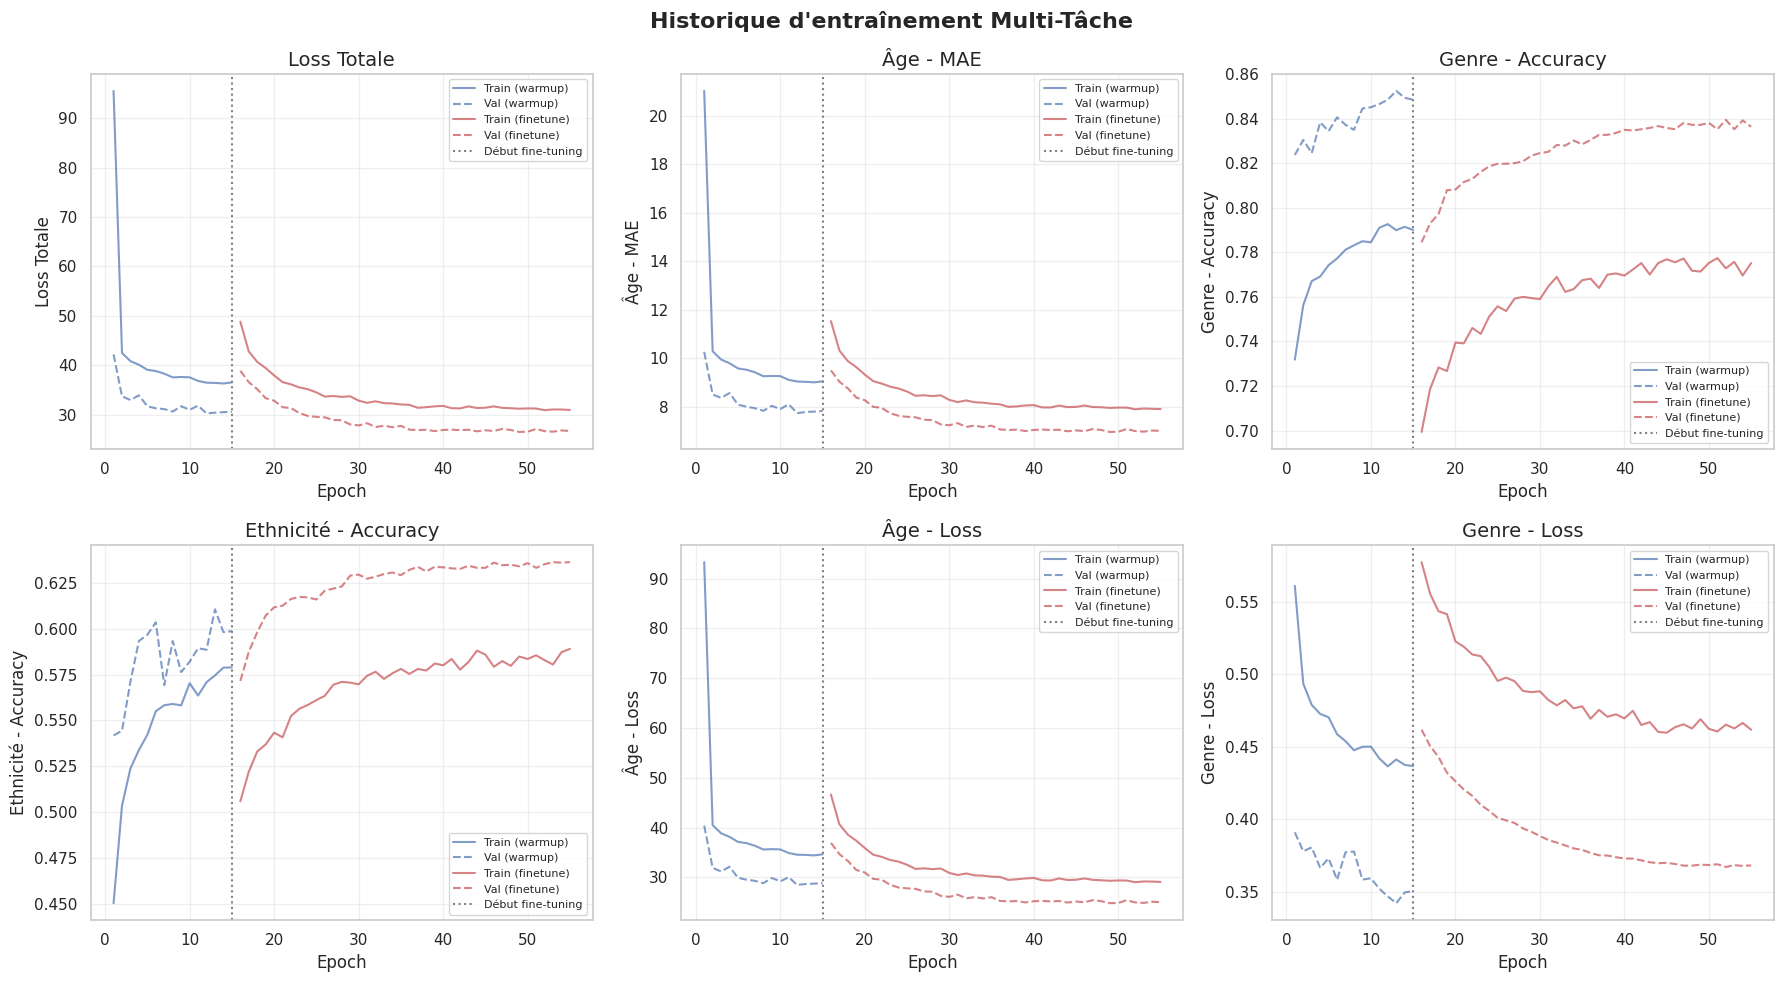

In [14]:
def plot_multitask_history(warmup_history, finetune_history):
    """Visualise l'historique d'entraînement multi-tâche."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Combiner les historiques
    warmup_epochs = len(warmup_history.history["loss"])

    metrics_to_plot = [
        ("loss", "Loss Totale"),
        ("age_output_mae", "Âge - MAE"),
        ("gender_output_accuracy", "Genre - Accuracy"),
        ("ethnicity_output_accuracy", "Ethnicité - Accuracy"),
        ("age_output_loss", "Âge - Loss"),
        ("gender_output_loss", "Genre - Loss"),
    ]

    for ax, (metric, title) in zip(axes.flat, metrics_to_plot):
        # Warmup
        if metric in warmup_history.history:
            train_warmup = warmup_history.history[metric]
            val_warmup = warmup_history.history.get(f"val_{metric}", [])

            epochs_warmup = range(1, len(train_warmup) + 1)
            ax.plot(
                epochs_warmup, train_warmup, "b-", label="Train (warmup)", alpha=0.7
            )
            if val_warmup:
                ax.plot(
                    epochs_warmup, val_warmup, "b--", label="Val (warmup)", alpha=0.7
                )

        # Fine-tuning
        if metric in finetune_history.history:
            train_ft = finetune_history.history[metric]
            val_ft = finetune_history.history.get(f"val_{metric}", [])

            epochs_ft = range(warmup_epochs + 1, warmup_epochs + len(train_ft) + 1)
            ax.plot(epochs_ft, train_ft, "r-", label="Train (finetune)", alpha=0.7)
            if val_ft:
                ax.plot(epochs_ft, val_ft, "r--", label="Val (finetune)", alpha=0.7)

        ax.axvline(
            x=warmup_epochs, color="gray", linestyle=":", label="Début fine-tuning"
        )
        ax.set_xlabel("Epoch")
        ax.set_ylabel(title)
        ax.set_title(title)
        ax.legend(loc="best", fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        "Historique d'entraînement Multi-Tâche", fontsize=16, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(
        ARTIFACTS_DIR / "multitask_training_history.png", dpi=150, bbox_inches="tight"
    )
    plt.show()


plot_multitask_history(warmup_history, finetune_history)

## 15. Évaluation sur le Test Set


In [15]:
# Charger le meilleur modèle
best_model = keras.models.load_model(ARTIFACTS_DIR / "multitask_model_best.keras")

# Évaluation
test_results = best_model.evaluate(test_ds, verbose=1)

# Afficher les résultats
print("\n" + "=" * 60)
print("RÉSULTATS SUR LE TEST SET")
print("=" * 60)

# Récupérer les noms des métriques
metric_names = best_model.metrics_names
for name, value in zip(metric_names, test_results):
    print(f"{name}: {value:.4f}")

111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - age_output_loss: 6.1803 - age_output_mae: 6.6571 - age_output_mse: 97.3332 - ethnicity_output_accuracy: 0.6243 - ethnicity_output_loss: 0.9820 - gender_output_accuracy: 0.8200 - gender_output_auc: 0.9105 - gender_output_loss: 0.3876 - loss: 7.8610 

RÉSULTATS SUR LE TEST SET
loss: 7.8610
compile_metrics: 6.1803
age_output_loss: 0.3876
gender_output_loss: 0.9820
ethnicity_output_loss: 6.6571


## 16. Prédictions Détaillées


In [16]:
# Prédictions
predictions = best_model.predict(test_ds, verbose=1)
y_pred_age = predictions[0].flatten()
y_pred_gender = (predictions[1].flatten() > 0.5).astype(int)
y_pred_gender_prob = predictions[1].flatten()
y_pred_ethnicity = np.argmax(predictions[2], axis=1)

# Métriques détaillées
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Âge
mae_age = np.mean(np.abs(y_age_test - y_pred_age))
rmse_age = np.sqrt(np.mean((y_age_test - y_pred_age) ** 2))

# Genre
acc_gender = accuracy_score(y_gender_test, y_pred_gender)
f1_gender = f1_score(y_gender_test, y_pred_gender)

# Ethnicité
acc_ethnicity = accuracy_score(y_eth_test, y_pred_ethnicity)
f1_ethnicity_macro = f1_score(y_eth_test, y_pred_ethnicity, average="macro")
f1_ethnicity_weighted = f1_score(y_eth_test, y_pred_ethnicity, average="weighted")

print("\n" + "=" * 60)
print("MÉTRIQUES DÉTAILLÉES")
print("=" * 60)
print(f"\n🎂 ÂGE:")
print(f"   MAE: {mae_age:.2f} années")
print(f"   RMSE: {rmse_age:.2f} années")
print(f"\n👫 GENRE:")
print(f"   Accuracy: {acc_gender*100:.2f}%")
print(f"   F1-Score: {f1_gender:.4f}")
print(f"\n🌍 ETHNICITÉ:")
print(f"   Accuracy: {acc_ethnicity*100:.2f}%")
print(f"   F1-Score (macro): {f1_ethnicity_macro:.4f}")
print(f"   F1-Score (weighted): {f1_ethnicity_weighted:.4f}")

111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step

MÉTRIQUES DÉTAILLÉES

🎂 ÂGE:
   MAE: 6.66 années
   RMSE: 9.87 années

👫 GENRE:
   Accuracy: 82.00%
   F1-Score: 0.7962

🌍 ETHNICITÉ:
   Accuracy: 62.43%
   F1-Score (macro): 0.4614
   F1-Score (weighted): 0.5794


## 17. Rapports de Classification


In [17]:
print("\n" + "=" * 60)
print("RAPPORT DE CLASSIFICATION - GENRE")
print("=" * 60)
print(classification_report(y_gender_test, y_pred_gender, target_names=GENDER_CLASSES))

print("\n" + "=" * 60)
print("RAPPORT DE CLASSIFICATION - ETHNICITÉ")
print("=" * 60)
print(
    classification_report(y_eth_test, y_pred_ethnicity, target_names=ETHNICITY_CLASSES)
)


RAPPORT DE CLASSIFICATION - GENRE
              precision    recall  f1-score   support

        Male       0.79      0.90      0.84      1851
      Female       0.87      0.74      0.80      1694

    accuracy                           0.82      3545
   macro avg       0.83      0.82      0.82      3545
weighted avg       0.83      0.82      0.82      3545


RAPPORT DE CLASSIFICATION - ETHNICITÉ
              precision    recall  f1-score   support

       White       0.62      0.91      0.73      1505
       Black       0.70      0.66      0.68       678
       Asian       0.59      0.45      0.51       512
      Indian       0.58      0.29      0.39       596
      Others       0.00      0.00      0.00       254

    accuracy                           0.62      3545
   macro avg       0.50      0.46      0.46      3545
weighted avg       0.58      0.62      0.58      3545



## 18. Matrices de Confusion


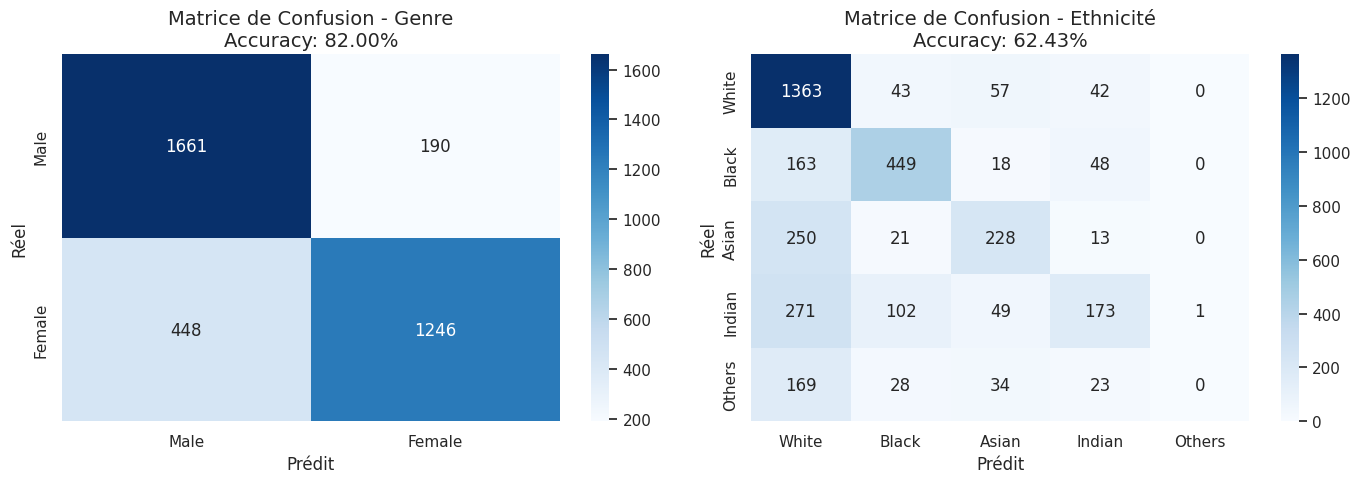

In [18]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion - Genre
cm_gender = confusion_matrix(y_gender_test, y_pred_gender)
sns.heatmap(
    cm_gender,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=GENDER_CLASSES,
    yticklabels=GENDER_CLASSES,
    ax=axes[0],
)
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")
axes[0].set_title(f"Matrice de Confusion - Genre\nAccuracy: {acc_gender*100:.2f}%")

# Matrice de confusion - Ethnicité
cm_ethnicity = confusion_matrix(y_eth_test, y_pred_ethnicity)
sns.heatmap(
    cm_ethnicity,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ETHNICITY_CLASSES,
    yticklabels=ETHNICITY_CLASSES,
    ax=axes[1],
)
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Réel")
axes[1].set_title(
    f"Matrice de Confusion - Ethnicité\nAccuracy: {acc_ethnicity*100:.2f}%"
)

plt.tight_layout()
plt.savefig(
    ARTIFACTS_DIR / "multitask_confusion_matrices.png", dpi=150, bbox_inches="tight"
)
plt.show()

## 19. Exemples de Prédictions


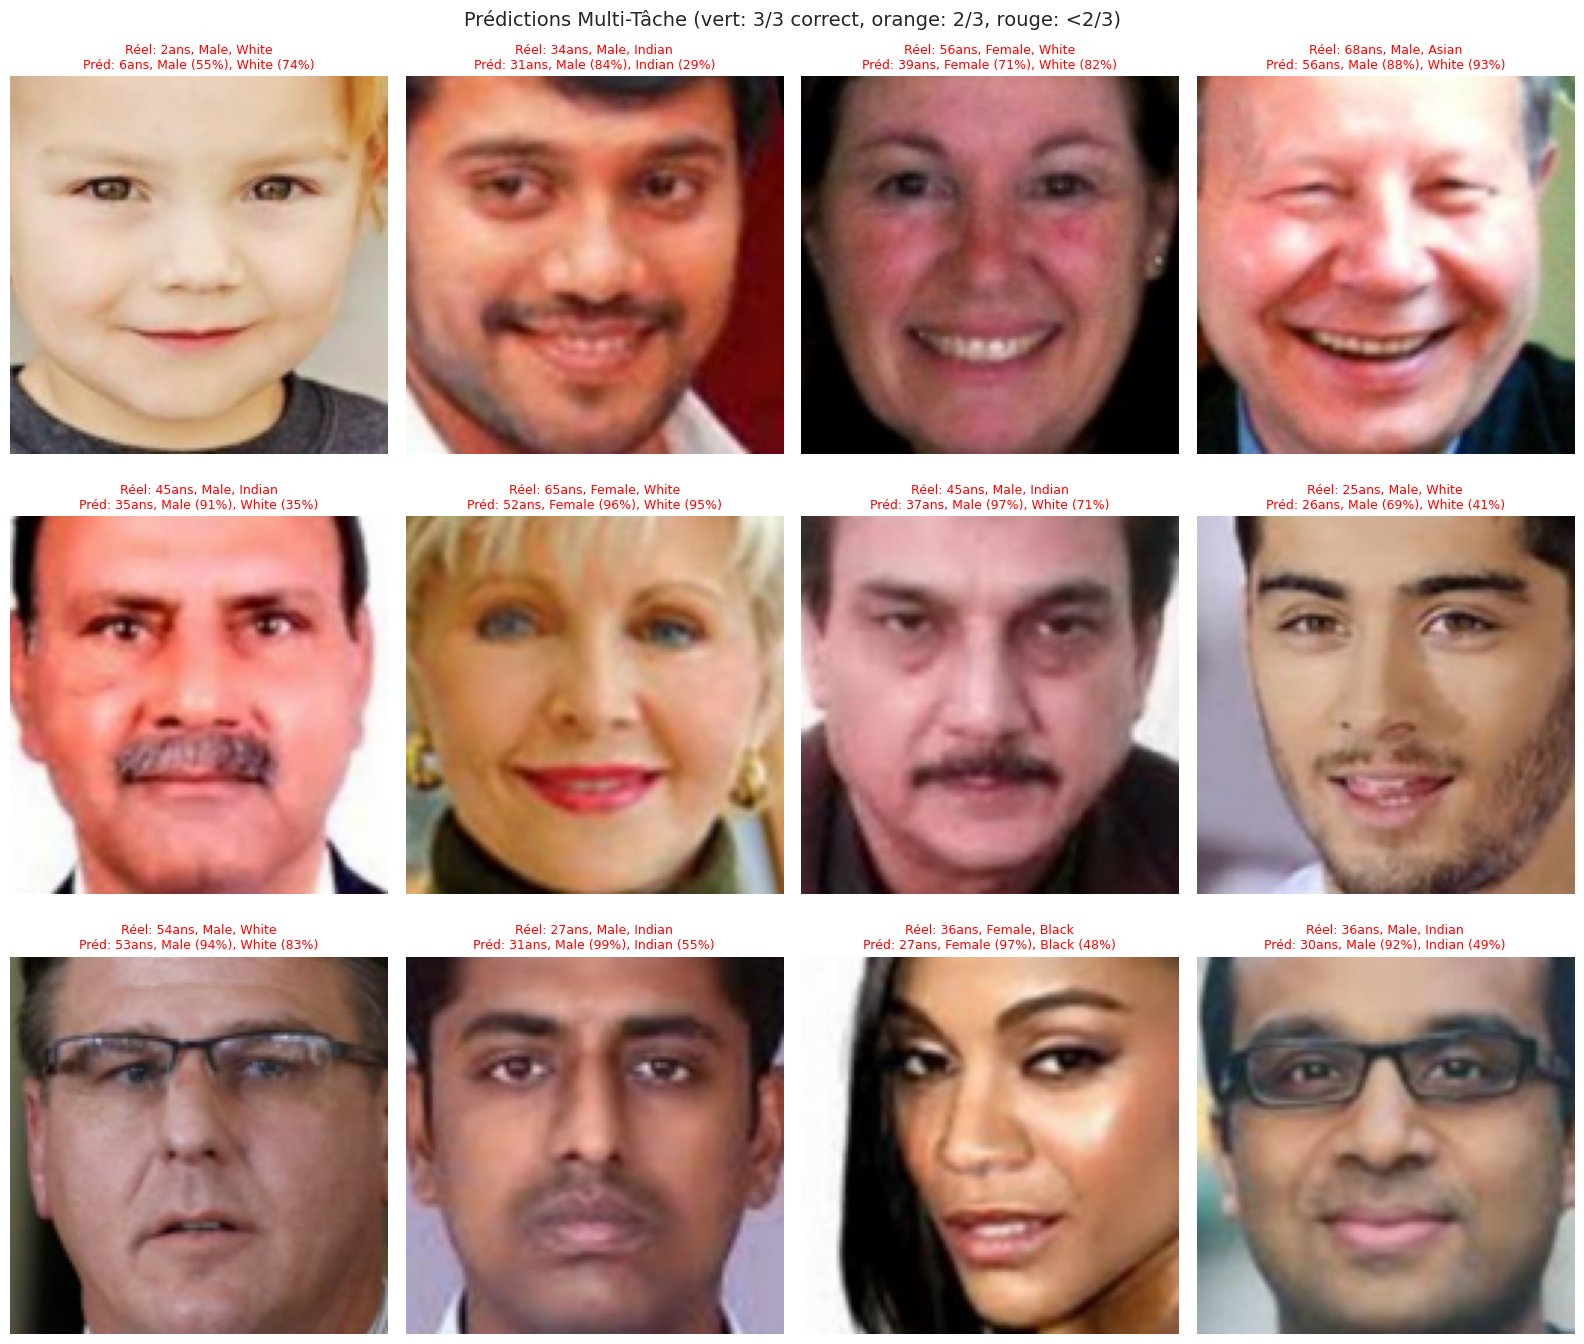

In [19]:
def show_multitask_predictions(
    model, filepaths, true_ages, true_genders, true_ethnicities, n_samples=12
):
    """Affiche des exemples de prédictions multi-tâche."""
    indices = np.random.choice(len(filepaths), n_samples, replace=False)
    fig, axes = plt.subplots(3, 4, figsize=(16, 14))

    for idx, ax in zip(indices, axes.flat):
        # Charger l'image
        img = Image.open(filepaths[idx]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img, dtype=np.float32)

        # Prédiction
        preds = model.predict(img_array[np.newaxis, ...], verbose=0)
        pred_age = preds[0][0, 0]
        pred_gender = "Female" if preds[1][0, 0] > 0.5 else "Male"
        pred_gender_conf = (
            preds[1][0, 0] if preds[1][0, 0] > 0.5 else 1 - preds[1][0, 0]
        )
        pred_eth_idx = np.argmax(preds[2][0])
        pred_eth = ETHNICITY_CLASSES[pred_eth_idx]
        pred_eth_conf = preds[2][0, pred_eth_idx]

        # Valeurs réelles
        true_age = true_ages[idx]
        true_gender = GENDER_CLASSES[true_genders[idx]]
        true_eth = ETHNICITY_CLASSES[true_ethnicities[idx]]

        # Erreurs
        age_error = abs(pred_age - true_age)
        gender_correct = pred_gender == true_gender
        eth_correct = pred_eth == true_eth

        # Couleur basée sur les erreurs
        n_correct = (age_error < 5) + gender_correct + eth_correct
        color = "green" if n_correct == 3 else ("orange" if n_correct >= 2 else "red")

        ax.imshow(img_array.astype(np.uint8))
        ax.set_title(
            f"Réel: {true_age:.0f}ans, {true_gender}, {true_eth}\n"
            f"Préd: {pred_age:.0f}ans, {pred_gender} ({pred_gender_conf*100:.0f}%), {pred_eth} ({pred_eth_conf*100:.0f}%)",
            fontsize=9,
            color=color,
        )
        ax.axis("off")

    plt.suptitle(
        "Prédictions Multi-Tâche (vert: 3/3 correct, orange: 2/3, rouge: <2/3)",
        fontsize=14,
    )
    plt.tight_layout()
    plt.savefig(
        ARTIFACTS_DIR / "multitask_predictions_examples.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()


show_multitask_predictions(best_model, X_test, y_age_test, y_gender_test, y_eth_test)

## 20. Sauvegarde du Modèle Final


In [20]:
# Sauvegarder le modèle final
final_model_path = ARTIFACTS_DIR / "multitask_model_final.keras"
best_model.save(final_model_path)
print(f"Modèle final sauvegardé: {final_model_path}")

Modèle final sauvegardé: artifacts/multitask_model_final.keras


## 21. Conversion TensorFlow Lite


In [21]:
# Conversion TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_model = converter.convert()

tflite_path = ARTIFACTS_DIR / "multitask_model.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

# Taille du fichier
tflite_size_mb = tflite_path.stat().st_size / (1024 * 1024)
print(f"Modèle TFLite sauvegardé: {tflite_path}")
print(f"Taille: {tflite_size_mb:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmp0__4z1dj/assets


INFO:tensorflow:Assets written to: /tmp/tmp0__4z1dj/assets


Saved artifact at '/tmp/tmp0__4z1dj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_image')
Output Type:
  List[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)]
Captures:
  130812735881872: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  130812735886672: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  130805241322896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130805241321936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130805241321168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130805241323664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130805241324240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130805241324432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  130805241321552

W0000 00:00:1768743340.879367   99420 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1768743340.879386   99420 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1768743340.983282   99420 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## 22. Sauvegarde des Métadonnées


In [22]:
import json

model_info = {
    "model_type": "multitask",
    "img_size": IMG_SIZE,
    "input_range": [0, 255],
    "outputs": {
        "age": {
            "type": "regression",
            "output_name": "age_output",
            "description": "Âge en années",
        },
        "gender": {
            "type": "binary_classification",
            "output_name": "gender_output",
            "classes": GENDER_CLASSES,
            "class_map": {"0": "Male", "1": "Female"},
            "threshold": 0.5,
        },
        "ethnicity": {
            "type": "multiclass_classification",
            "output_name": "ethnicity_output",
            "classes": ETHNICITY_CLASSES,
            "class_map": {str(i): c for i, c in enumerate(ETHNICITY_CLASSES)},
        },
    },
    "metrics": {
        "age_mae": float(mae_age),
        "age_rmse": float(rmse_age),
        "gender_accuracy": float(acc_gender),
        "gender_f1": float(f1_gender),
        "ethnicity_accuracy": float(acc_ethnicity),
        "ethnicity_f1_macro": float(f1_ethnicity_macro),
        "ethnicity_f1_weighted": float(f1_ethnicity_weighted),
    },
}

info_path = ARTIFACTS_DIR / "multitask_model_info.json"
with open(info_path, "w") as f:
    json.dump(model_info, f, indent=2)

print(f"Métadonnées sauvegardées: {info_path}")
print(json.dumps(model_info, indent=2))

Métadonnées sauvegardées: artifacts/multitask_model_info.json
{
  "model_type": "multitask",
  "img_size": 128,
  "input_range": [
    0,
    255
  ],
  "outputs": {
    "age": {
      "type": "regression",
      "output_name": "age_output",
      "description": "\u00c2ge en ann\u00e9es"
    },
    "gender": {
      "type": "binary_classification",
      "output_name": "gender_output",
      "classes": [
        "Male",
        "Female"
      ],
      "class_map": {
        "0": "Male",
        "1": "Female"
      },
      "threshold": 0.5
    },
    "ethnicity": {
      "type": "multiclass_classification",
      "output_name": "ethnicity_output",
      "classes": [
        "White",
        "Black",
        "Asian",
        "Indian",
        "Others"
      ],
      "class_map": {
        "0": "White",
        "1": "Black",
        "2": "Asian",
        "3": "Indian",
        "4": "Others"
      }
    }
  },
  "metrics": {
    "age_mae": 6.657143592834473,
    "age_rmse": 9.865758895874

## 23. Résumé Final


In [23]:
print("=" * 60)
print("RÉSUMÉ DU MODÈLE MULTI-TÂCHE")
print("=" * 60)
print(f"\nArchitecture: EfficientNetB0 + 3 Heads spécialisés")
print(f"Input size: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"Dataset: {len(df_clean)} images")
print(f"  - Train: {len(X_train)}")
print(f"  - Val: {len(X_val)}")
print(f"  - Test: {len(X_test)}")
print(f"\nPerformances sur le test set:")
print(f"  🎂 Âge:")
print(f"     - MAE: {mae_age:.2f} années")
print(f"     - RMSE: {rmse_age:.2f} années")
print(f"  👫 Genre:")
print(f"     - Accuracy: {acc_gender*100:.2f}%")
print(f"     - F1-Score: {f1_gender:.4f}")
print(f"  🌍 Ethnicité:")
print(f"     - Accuracy: {acc_ethnicity*100:.2f}%")
print(f"     - F1-Score (macro): {f1_ethnicity_macro:.4f}")
print(f"\nFichiers sauvegardés:")
print(f"  - {final_model_path}")
print(f"  - {tflite_path} ({tflite_size_mb:.2f} MB)")
print(f"  - {info_path}")
print("=" * 60)

RÉSUMÉ DU MODÈLE MULTI-TÂCHE

Architecture: EfficientNetB0 + 3 Heads spécialisés
Input size: 128x128x3
Dataset: 23633 images
  - Train: 16543
  - Val: 3545
  - Test: 3545

Performances sur le test set:
  🎂 Âge:
     - MAE: 6.66 années
     - RMSE: 9.87 années
  👫 Genre:
     - Accuracy: 82.00%
     - F1-Score: 0.7962
  🌍 Ethnicité:
     - Accuracy: 62.43%
     - F1-Score (macro): 0.4614

Fichiers sauvegardés:
  - artifacts/multitask_model_final.keras
  - artifacts/multitask_model.tflite (10.58 MB)
  - artifacts/multitask_model_info.json
